In [1]:
import numpy as np

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.decomposition import PCA
from sklearn.metrics import fbeta_score, confusion_matrix, precision_score

import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns

import shap

import utils
import hdbscan

from sklearn.neighbors import KNeighborsClassifier



sns.set_theme(style="whitegrid")
#f2_scorer = make_scorer(fbeta_score, beta=2, zero_division=0)

DATASET_PATH = "data/BRFSS2.csv"
TARGET = "Heart_Disease"

SEED = 42

c:\Users\lucas\anaconda3\envs\speech\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# load dataset
X, y = utils.load_dataset(DATASET_PATH, TARGET)

# we use a hierarchical split
# 1. split the data in 80% train and 20% test
# 2. split the train again in 80% train and 20% val
feat_names = utils.feat_names(DATASET_PATH, TARGET)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=SEED, stratify=y)

X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.3, random_state=SEED, stratify=y_train
)

c:\Users\lucas\anaconda3\envs\speech\Lib\site-packages\sklearn\linear_model\_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(


Metric     | 
Accuracy   | 0.7322    
Precision  | 0.2024    
Recall     | 0.7860    
F1-Score   | 0.3219    
F2-Score   | 0.4985    
AUPRC      | 0.3027    



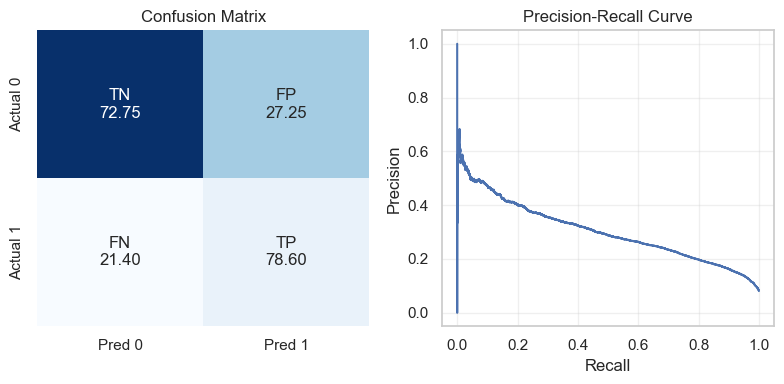

In [3]:
logreg_clf = Pipeline(steps=[
    ('scaler', MinMaxScaler()),
    ('clf', LogisticRegression(C=10, penalty="l2", class_weight="balanced", random_state=SEED, solver="saga"))
])

logreg_clf.fit(X_train, y_train)
y_val_probs = logreg_clf.predict_proba(X_val)[:, 1]
metrics, fig, _ = utils.compute_metrics(y_val, y_val_probs)
print(metrics)
plt.figure(fig.number)
plt.show()

# Leveraging Explainable AI

Since the logistic regression model achieved the best F2 score, we will use it from now on.

The idea is to leverage SHAP values to perform clustering in order to identify clinical phenotypes for which the model is unreliable. This information is crucial for understanding the model’s limitations, specifically determining when its predictions can be trusted and when they should be interpreted with caution.

This is particularly important in the medical field, identifying subgroups of patients associated with poor model reliability can support safer deployment, and help to recognize cases that may require additional validation or expert assessment

In [4]:
# going from the raw data manifold into the shap manifold
model = logreg_clf.named_steps['clf']
scaler = logreg_clf.named_steps['scaler']

X_train_scal = scaler.transform(X_train)
X_val_scal = scaler.transform(X_val)
X_test_scal = scaler.transform(X_test)

explainer = shap.LinearExplainer(model, X_train_scal)
shap_val = explainer(X_val_scal)
shap_val.feature_names = feat_names
shap_val_values = shap_val.values

shap_test = explainer(X_test_scal)
shap_test.feature_names = feat_names
shap_test_values = shap_test.values

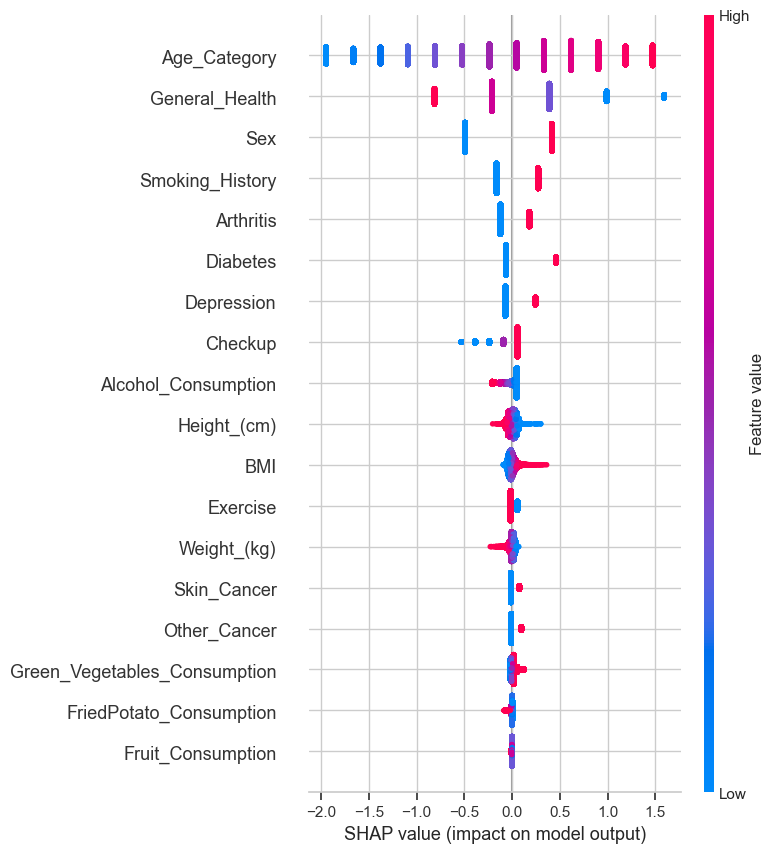

In [5]:
shap.summary_plot(shap_val, X_val_scal)

In [6]:
pca = PCA(n_components=2, random_state=SEED)
shap_val_values_2d = pca.fit_transform(shap_val_values)
shap_test_values_2d = pca.fit_transform(shap_test_values)

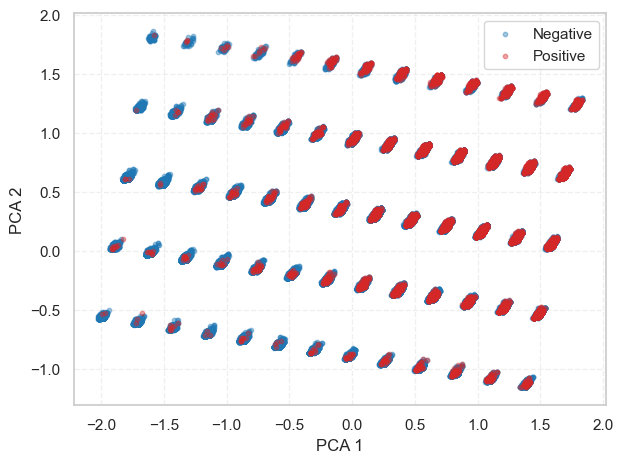

In [7]:
import matplotlib.pyplot as plt

plt.figure()

plt.scatter(
    shap_val_values_2d[y_val == 0, 0], shap_val_values_2d[y_val == 0, 1],
    color="tab:blue", alpha=0.4, s=10, label="Negative"
)

plt.scatter(
    shap_val_values_2d[y_val == 1, 0], shap_val_values_2d[y_val == 1, 1],
    color="tab:red", alpha=0.4, s=10, label="Positive" 
)

plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.grid(True, linestyle="--", alpha=0.3)

plt.legend()

plt.tight_layout()
plt.show()

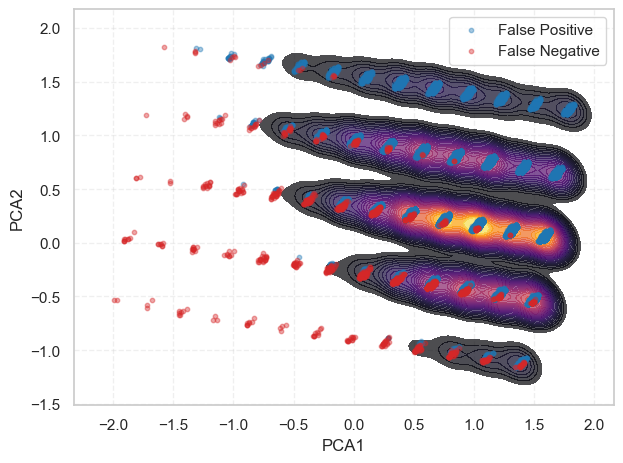

In [8]:
y_val_pred = (y_val_probs >= 0.5).astype(int)

tn = (y_val == 0) & (y_val_pred == 0)
tp = (y_val == 1) & (y_val_pred == 1)
fp = (y_val == 0) & (y_val_pred == 1)
fn = (y_val == 1) & (y_val_pred == 0)
errors = fp | fn

plt.figure()

sns.kdeplot(
    x=shap_val_values_2d[errors, 0],
    y=shap_val_values_2d[errors, 1],
    cmap="inferno",
    fill=True,
    alpha=0.7,
    levels=30
)

plt.scatter(
    shap_val_values_2d[fp, 0], 
    shap_val_values_2d[fp, 1],
    color="tab:blue",
    alpha=0.4, 
    s=10, 
    label="False Positive"
)

plt.scatter(
    shap_val_values_2d[fn, 0], 
    shap_val_values_2d[fn, 1],
    color="tab:red",
    alpha=0.4, 
    s=10, 
    label="False Negative"
)

plt.xlabel("PCA1")
plt.ylabel("PCA2")
plt.grid(True, linestyle="--", alpha=0.3)

plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

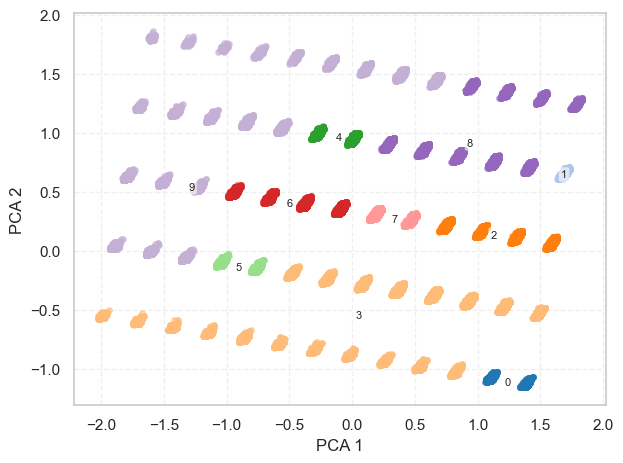

In [9]:
# to capture complex structures and having clusters statistically meaningful we use the hdbscan
# which let us to set the minimum number of samples for each cluster

clusterer = hdbscan.HDBSCAN(
    min_cluster_size=300,
    min_samples=10,
    cluster_selection_epsilon=0.5,
    prediction_data=True
)
cluster_val_labels = clusterer.fit_predict(shap_val_values_2d)

unique_clusters = np.unique(cluster_val_labels)
unique_clusters = unique_clusters[unique_clusters != -1]

plt.figure()

cmap = plt.get_cmap('tab20')

noise_mask = (cluster_val_labels == -1)
plt.scatter(
    shap_val_values_2d[noise_mask, 0], shap_val_values_2d[noise_mask, 1],
    color="black", alpha=0.6, s=15, marker='x', label="Noise"
)

for c_id in unique_clusters:
    c_mask = (cluster_val_labels == c_id)
    color = cmap(c_id % 20)
    
    plt.scatter(
        shap_val_values_2d[c_mask, 0], shap_val_values_2d[c_mask, 1],
        color=color, alpha=0.6, s=15, label=f'Cluster {c_id}'
    )
    
    c_x = np.mean(shap_val_values_2d[c_mask, 0])
    c_y = np.mean(shap_val_values_2d[c_mask, 1])
    
    txt = plt.text(
        c_x, c_y, str(c_id), fontsize=8, 
        ha='center', va='center',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2')
    )

plt.xlabel("PCA 1", fontsize=12)
plt.ylabel("PCA 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)


plt.tight_layout()
plt.show()

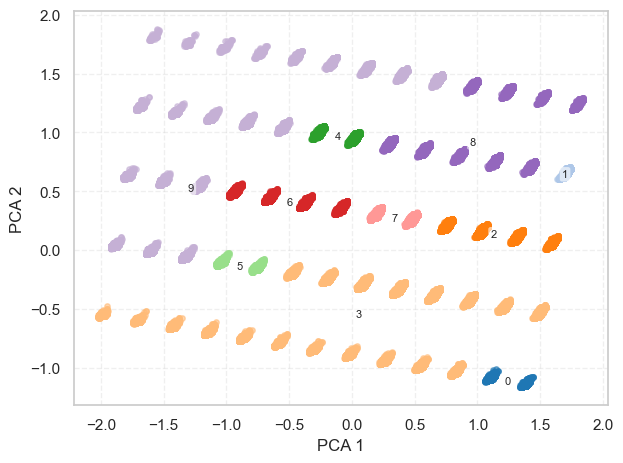

In [10]:
def fit_hdbscan_with_knn(X_train, y_train, X_to_fit, n_neighbors=3):
    
    train_mask = (y_train != -1)        
    X_train = X_train[train_mask]
    y_train = y_train[train_mask]
    
    knn = KNeighborsClassifier(n_neighbors=n_neighbors, weights='distance', n_jobs=-1)
    knn.fit(X_train, y_train)
    
    y_pred = knn.predict(X_to_fit)
    
    return y_pred

cluster_test_labels = fit_hdbscan_with_knn(
    shap_val_values_2d, 
    cluster_val_labels, 
    shap_test_values_2d)

cmap = plt.get_cmap('tab20')

noise_mask = (cluster_test_labels == -1)
plt.figure()
plt.scatter(
    shap_test_values_2d[noise_mask, 0], shap_test_values_2d[noise_mask, 1],
    color="black", alpha=0.6, s=15, marker='x', label="Noise"
)

for c_id in unique_clusters:
    c_mask = (cluster_test_labels == c_id)
    color = cmap(c_id % 20)
    
    plt.scatter(
        shap_test_values_2d[c_mask, 0], shap_test_values_2d[c_mask, 1],
        color=color, alpha=0.6, s=15, label=f'Cluster {c_id}'
    )
    
    c_x = np.mean(shap_test_values_2d[c_mask, 0])
    c_y = np.mean(shap_test_values_2d[c_mask, 1])
    
    txt = plt.text(
        c_x, c_y, str(c_id), fontsize=8, 
        ha='center', va='center',
        bbox=dict(facecolor='white', alpha=0.6, edgecolor='none', boxstyle='round,pad=0.2')
    )

plt.xlabel("PCA 1", fontsize=12)
plt.ylabel("PCA 2", fontsize=12)
plt.grid(True, linestyle="--", alpha=0.3)


plt.tight_layout()
plt.show()

In [11]:
# we leverage groups discovery on the shap manifold 
# to identify regions where the model reasoning
# is reliable and regions where it is less reliable

# for each cluster, we estimate the confidence of the model predictions
# this is useful in a clinical setting, where it is important
# to provide not only the predicted classification, but also an estimate
# of how much a doctor can trust that prediction

# we define the positive confidence as the proportion of correctly predicted
# positive samples within the cluster (i.e. positive precision)
# and the negative confidence as the proportion of correctly
# predicted negative samples within the cluster
# obtaining a lookup table that assigns to each cluster the positive
# and negative confidence

# during the inference, once a sample is assigned to a cluster, we can retrieve
# the corresponding confidence scores computed on the validation set enriching
# the prediction with its reliability

def compute_conf(y, y_pred, cluster_labels):
    unique_clusters = np.unique(cluster_labels)
    unique_clusters = unique_clusters[unique_clusters != -1]

    lt = np.zeros((len(unique_clusters), 2))

    for c_id in unique_clusters:
        c_mask = (cluster_labels == c_id)

        y_true_c = y[c_mask]
        y_pred_c = y_pred[c_mask]

        pos_conf = precision_score(y_true_c, y_pred_c, pos_label=1, zero_division=0.0)
        neg_conf = precision_score(y_true_c, y_pred_c, pos_label=0, zero_division=0.0)

        lt[c_id] = [pos_conf, neg_conf]
    
    return lt

val_conf_lt = compute_conf(y_val, y_val_pred, cluster_labels=cluster_val_labels)

print(f"{'cluster':^7} | {'pos precision':^12} | {'neg precision':^14}")
print("-" * 40)

for c_id in unique_clusters:
    pos_conf, neg_conf = val_conf_lt[c_id]
    print(f"{c_id:>7} | {pos_conf:>12.2} | {neg_conf:>14.2}")

cluster | pos precision | neg precision 
----------------------------------------
      0 |         0.13 |           0.94
      1 |         0.34 |            0.0
      2 |         0.19 |           0.95
      3 |         0.14 |           0.97
      4 |         0.13 |           0.91
      5 |          0.0 |           0.99
      6 |        0.078 |           0.97
      7 |         0.13 |           0.95
      8 |         0.28 |            0.9
      9 |         0.25 |           0.99


Metric     | 
Accuracy   | 0.7362    
Precision  | 0.2064    
Recall     | 0.7955    
F1-Score   | 0.3278    
F2-Score   | 0.5065    
AUPRC      | 0.3115    



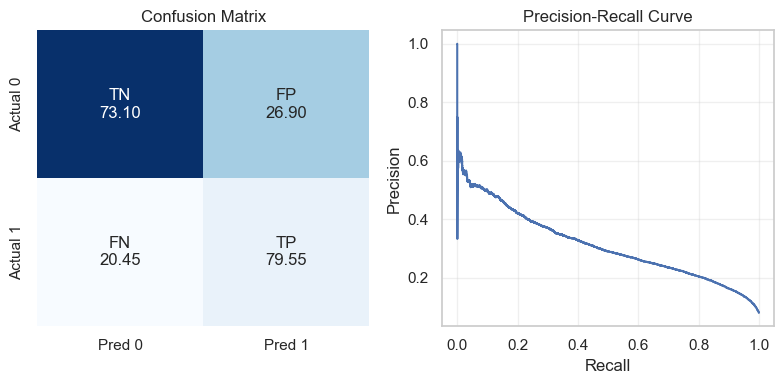

conf >= 95%:       58693 samples | 63.34%
70% <= conf < 95%: 5098 samples |  5.50%
conf < 70%:        28866 samples | 31.15%


In [12]:
y_test_probs = model.predict_proba(X_test_scal)[:, 1]
y_test_pred = (y_test_probs >= 0.5).astype(int)

test_conf = np.zeros(len(y_test_pred))

for c_id in unique_clusters:
    pos_conf, neg_conf = val_conf_lt[c_id]
    
    c_mask = (cluster_test_labels == c_id)
    
    test_conf[c_mask] = np.where(
        y_test_pred[c_mask] == 1, 
        pos_conf, neg_conf 
    )

top  = (test_conf >= 0.95)
mid  = (test_conf < 0.95) & (test_conf >= 0.7)
low = (test_conf < 0.7) | np.isnan(test_conf)

total_test = len(y_test)

metrics, fig, _ = utils.compute_metrics(y_test, y_test_probs)
print(metrics)
plt.figure(fig.number)
plt.show()

print(f"conf >= 95%:       {np.sum(top)} samples | {np.sum(top)/total_test:>6.2%}")
print(f"70% <= conf < 95%: {np.sum(mid)} samples | {np.sum(mid)/total_test:>6.2%}")
print(f"conf < 70%:        {np.sum(low)} samples | {np.sum(low)/total_test:>6.2%}")

In [13]:
comparison = np.zeros((val_conf_lt.shape[0], 2))
weighted_diff = np.zeros(2)
weight = np.zeros(2)

test_conf_lt = compute_conf(y_test, y_test_pred, cluster_labels=cluster_test_labels)

print(f"{'Cluster':^6} | {'pos_diff':^8} | {'neg_diff':^8}")
print("-" * 30)

for c_id in unique_clusters:

    val_pos_conf, val_neg_conf = val_conf_lt[c_id]
    test_pos_conf, test_neg_conf = test_conf_lt[c_id]
    
    pos_diff = np.abs(val_pos_conf - test_pos_conf) if not (np.isnan(val_pos_conf) or np.isnan(test_pos_conf)) else np.nan
    neg_diff = np.abs(val_neg_conf - test_neg_conf) if not (np.isnan(val_neg_conf) or np.isnan(test_neg_conf)) else np.nan

    mask = (cluster_test_labels == c_id)
    y_true_c = y_test[mask]
    y_pred_c = y_test_pred[mask]
    tn, fp, fn, tp = confusion_matrix(y_true_c, y_pred_c, labels=[0, 1]).ravel()

    comparison[c_id] = [pos_diff, neg_diff]

    pos_w = tp + fp
    if not np.isnan(pos_diff) and pos_w > 0:
        weighted_diff[0] += pos_diff * pos_w
        weight[0] += pos_w
        
    neg_w = tn + fn
    if not np.isnan(neg_diff) and neg_w > 0:
        weighted_diff[1] += neg_diff * neg_w
        weight[1] += neg_w
    
    
    print(f"{int(c_id):^6} | {pos_diff:^8.2f} | {neg_diff:^8.2f}")

print("-" * 30)

wmae_pos = weighted_diff[0] / weight[0] if weight[0] > 0 else 0.0
wmae_neg = weighted_diff[1] / weight[1] if weight[1] > 0 else 0.0

print(f"Weighted MAE (Pos): {wmae_pos:.2}")
print(f"Weighted MAE (Neg): {wmae_neg:.2}")

Cluster | pos_diff | neg_diff
------------------------------
  0    |   0.06   |   0.00  
  1    |   0.00   |   0.00  
  2    |   0.01   |   0.02  
  3    |   0.01   |   0.00  
  4    |   0.01   |   0.03  
  5    |   0.00   |   0.00  
  6    |   0.05   |   0.00  
  7    |   0.01   |   0.00  
  8    |   0.01   |   0.04  
  9    |   0.01   |   0.00  
------------------------------
Weighted MAE (Pos): 0.0085
Weighted MAE (Neg): 0.0021
